# Imports

In [284]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli

# Create GP world

In [641]:
## define the GP model
class GP_world():

    def __init__(self, N, params=None):
        
        ## initialise the GP grid
        self.N = N
        x = np.arange(N)
        y = np.arange(N)
        X,Y = np.meshgrid(x,y)
        self.locations = np.column_stack([X.ravel(), Y.ravel()])

        ## set the kernel parameters
        if params is None:
            self.c = 0
            self.scale = 1.0
            self.theta = 0
            self.sigma_f = 1.0
            self.length_scale = 2
            self.periodic_length_scale = 4
            self.period = 8
            self.periodic_theta = 0
        else:
            self.c = params['c']
            self.scale = params['scale']
            self.theta = params['theta']
            self.sigma_f = params['sigma_f']
            self.length_scale = params['length_scale']
            self.periodic_length_scale = params['periodic_length_scale']
            self.period = params['period']
            self.periodic_theta = params['periodic_theta']



        ## initialise the kernels
        self.K_lin = self.linear()
        self.K_lin_x = self.linear_1D(0)
        self.K_lin_y = self.linear_1D(1)
        self.K_rbf = self.rbf()
        self.K_rbf_x = self.rbf_1D(0)
        self.K_rbf_y = self.rbf_1D(1)
        self.K_periodic_x = self.periodic(0)
        self.K_periodic_y = self.periodic(1)


    #### define the kernels


    ## linear kernels
    
    # linear kernel over x,y, i.e. similarity as a function of the distance from the origin (0,0)
    def linear(self):
        dists = np.sqrt(self.locations[:, 0]**2 + self.locations[:, 1]**2)
        K = np.outer(dists, dists) + self.c
        return K
    
    # linear kernel over x-distance (0) or y-distance (1), i.e. similarity as a function of the distance from (0,:) or (:,0), where the basis vectors are determined by the angle theta (in radians)
    def linear_1D(self, dim = 0):
        rotation = np.array([[np.cos(self.theta), -np.sin(self.theta)], [np.sin(self.theta), np.cos(self.theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.scale**2 * dists
        return K
    

    ## RBFs 

    # RBF kernel over x,y (i.e. Euclidean distance)
    def rbf(self):
        dists = cdist(self.locations, self.locations, metric='euclidean')
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K

    # RBF kernel over just x-distance or y-distance
    def rbf_1D(self, dim=0):
        dists = np.subtract.outer(self.locations[:, dim], self.locations[:, dim])
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K
    

    ## periodic kernel
    def periodic(self, dim=0):
        rotation = np.array([[np.cos(self.periodic_theta), -np.sin(self.periodic_theta)], [np.sin(self.periodic_theta), np.cos(self.periodic_theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.sigma_f**2 * np.exp(-2 * np.sin(np.pi * dists / self.period)**2 / self.periodic_length_scale**2)
        return K
    
    ## __call__ Method
    # def __call__(self, kernel_types, **kwargs):
        
    #     ## composite kernel
    #     if isinstance(kernel_types, list):

    #         # if operations is None or len(kernel_types) != len(operation) + 1:
    #         #     raise ValueError("Must provide a list of operations with one less element than the list of kernels.")
            
    #         # start with the first kernel
    #         K_1 = self.compute_kernel(kernel_types[0], **kwargs)
    #         K_2 = self.compute_kernel(kernel_types[1], **kwargs)
    #         K = self.combine_kernels(K_1, K_2, kernel_types[2])

    #         # Combine the subsequent kernels
    #         # for i, op in enumerate(operations):
    #         #     K_next = self.compute_kernel(kernel_types[i+1], **kwargs)
    #         #     K = self.combine_kernels(K, K_next, operation=op)

    #     ## base kernel
    #     else:
    #         K = self.compute_kernel(kernel_types, **kwargs)
        
            
    #     return K
    
    # ## compute the kernel
    # def compute_kernel(self, kernel_type, **kwargs):
    #     if kernel_type == 'linear':
    #         return self.linear(**kwargs)
    #     elif kernel_type == 'linear_1D':
    #         return self.linear_1D(**kwargs)
    #     elif kernel_type == 'rbf':
    #         return self.rbf(**kwargs)
    #     elif kernel_type == 'rbf_1D':
    #         return self.rbf_1D(**kwargs)
    #     elif kernel_type == 'periodic':
    #         return self.periodic(**kwargs)
    #     else:
    #         raise ValueError(f"Unknown kernel type: {kernel_type}")
        
        
    ## combine the kernels
    # def combine_kernels(self, K1, K2, operation):
    #     if operation == '+':
    #         return K1 + K2
    #     elif operation == '*':
    #         return K1 * K2
    #     else:
    #         raise ValueError(f"Unknown operation: {operation}")

    ## sample from the GP
    def sample(self, K, **kwargs):
        # K = self(kernel_types, **kwargs)
        mean = np.zeros(self.N**2)
        samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)

        #normalise
        samples = (samples - np.min(samples))/np.max(samples)-np.min(samples)
        return samples
    
    ## posterior prediction
    def post_pred(self, K, inpt_idx, obs_idx, obs_rewards, sigma = 0.01):
        K_inpts = K[inpt_idx][obs_idx].T #i.e. the covariance of the points you're trying to predict (in this case, all of them), and the points you've observed
        K_obs = K[obs_idx,obs_idx] #i.e. the covariance of the points you've observed
        inv_K = np.linalg.inv(K_obs + sigma* np.eye(len(K_obs)))
        post_mean = K_inpts@inv_K@obs_rewards
        post_cov = K[inpt_idx, inpt_idx] - K_inpts@inv_K@K_obs.T 
        return post_mean.reshape(self.N,self.N) #this will need to be the shape of the inpts 

    
    ## visualise the samples
    def plot_r(self, sampled_rewards, ax, title=None):
        ax.imshow(sampled_rewards, extent=(0, self.N, 0, self.N), origin='lower')
        # ax.set_xticks(np.arange(0, self.N+1, 5))
        # ax.set_yticks(np.arange(0, self.N+1, 5))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(title)
        # ax.set_title('Sampled Reward Distribution,\nkernel: {}'.format(self.kernel_type))
        return ax
    

/var/folders/0_/bfm0814102bf5r7kyrp8f9tw19dth1/T/ipykernel_75054/291671861.py:144: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)


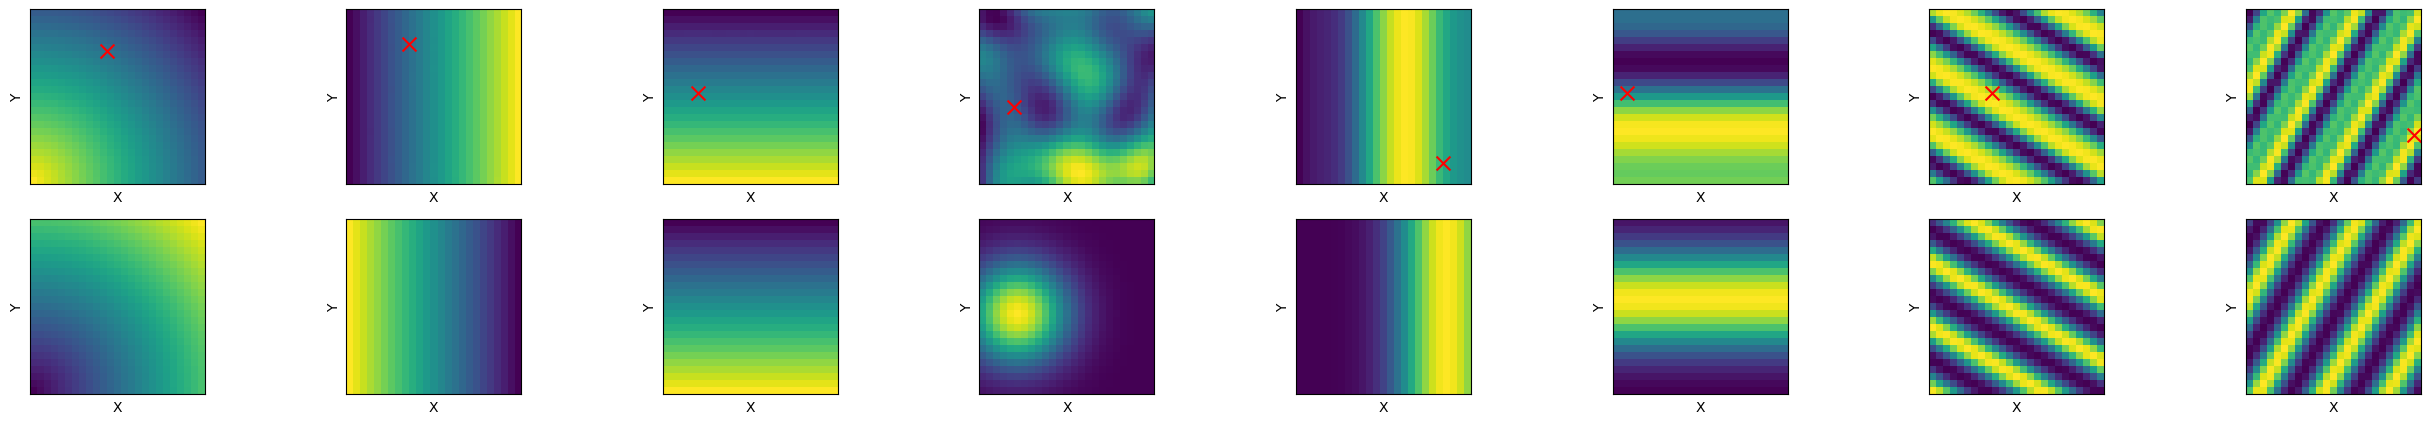

In [660]:
## initialise the GP
GP_params = {
    'c': 0,
    'scale': 1,
    'theta': 0,
    # 'theta': np.pi/4,
    'sigma_f': 1,
    'length_scale': 5,
    'period': 8,
    'periodic_length_scale': 2,
    'periodic_theta': np.pi/3,
}
N = 25
GP = GP_world(N, GP_params)

## define base kernels of interest
# koi = ['linear', 'linear_1D', 'rbf', 'rbf_1D','periodic', ['rbf', 'periodic','+']]
#        , ['linear', 'rbf', 'linear', 'rbf']]
koi = [GP.K_lin, GP.K_lin_x, GP.K_lin_y, GP.K_rbf, 
       GP.K_rbf_x, GP.K_rbf_y, 
       GP.K_periodic_x, GP.K_periodic_y]
kernel_names = ['Linear', 'Linear_x', 'Linear_y', 'RBF', 
                'RBF_x', 'RBF_y', 
                'Periodic_x', 'Periodic_y']
n_koi = len(koi)
fig, axs = plt.subplots(2, n_koi, figsize=(4*n_koi, 5))

## loop through kernel types and sample the GP under each kernel
for ki, k in enumerate(koi):
    samples = GP.sample(k)
    GP.plot_r(samples, axs[0,ki])

    ## select 5 reward obs to present to the agent
    n_obs = 1
    obs_idx = np.random.randint(0,N**2, size=n_obs)
    obs_coords = GP.locations[obs_idx]
    axs[0,ki].scatter(obs_coords[:,0], obs_coords[:,1], c='r', s=100, marker='x')
    obs_rewards = samples[obs_coords[:,0], obs_coords[:,1]]

    ## use GP regression to predict posterior distribution of rewards, given these obs
    inpt_idx = np.arange(N**2)
    post_mean = GP.post_pred(k, inpt_idx, obs_idx, obs_rewards)
    # sns.heatmap(post_mean, ax = axs[1,ki])
    GP.plot_r(post_mean, axs[1,ki])


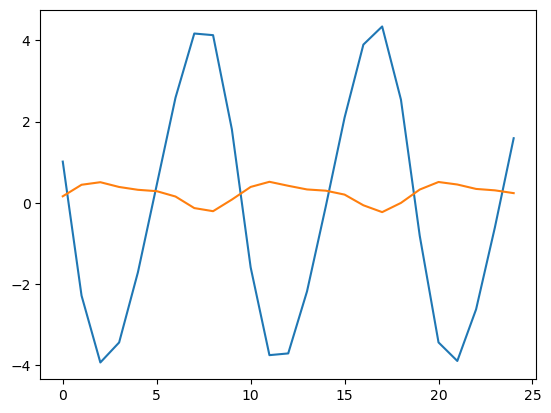

In [659]:
plt.plot(post_mean[0])
plt.plot(samples[0])

/var/folders/0_/bfm0814102bf5r7kyrp8f9tw19dth1/T/ipykernel_75054/2749279937.py:144: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)


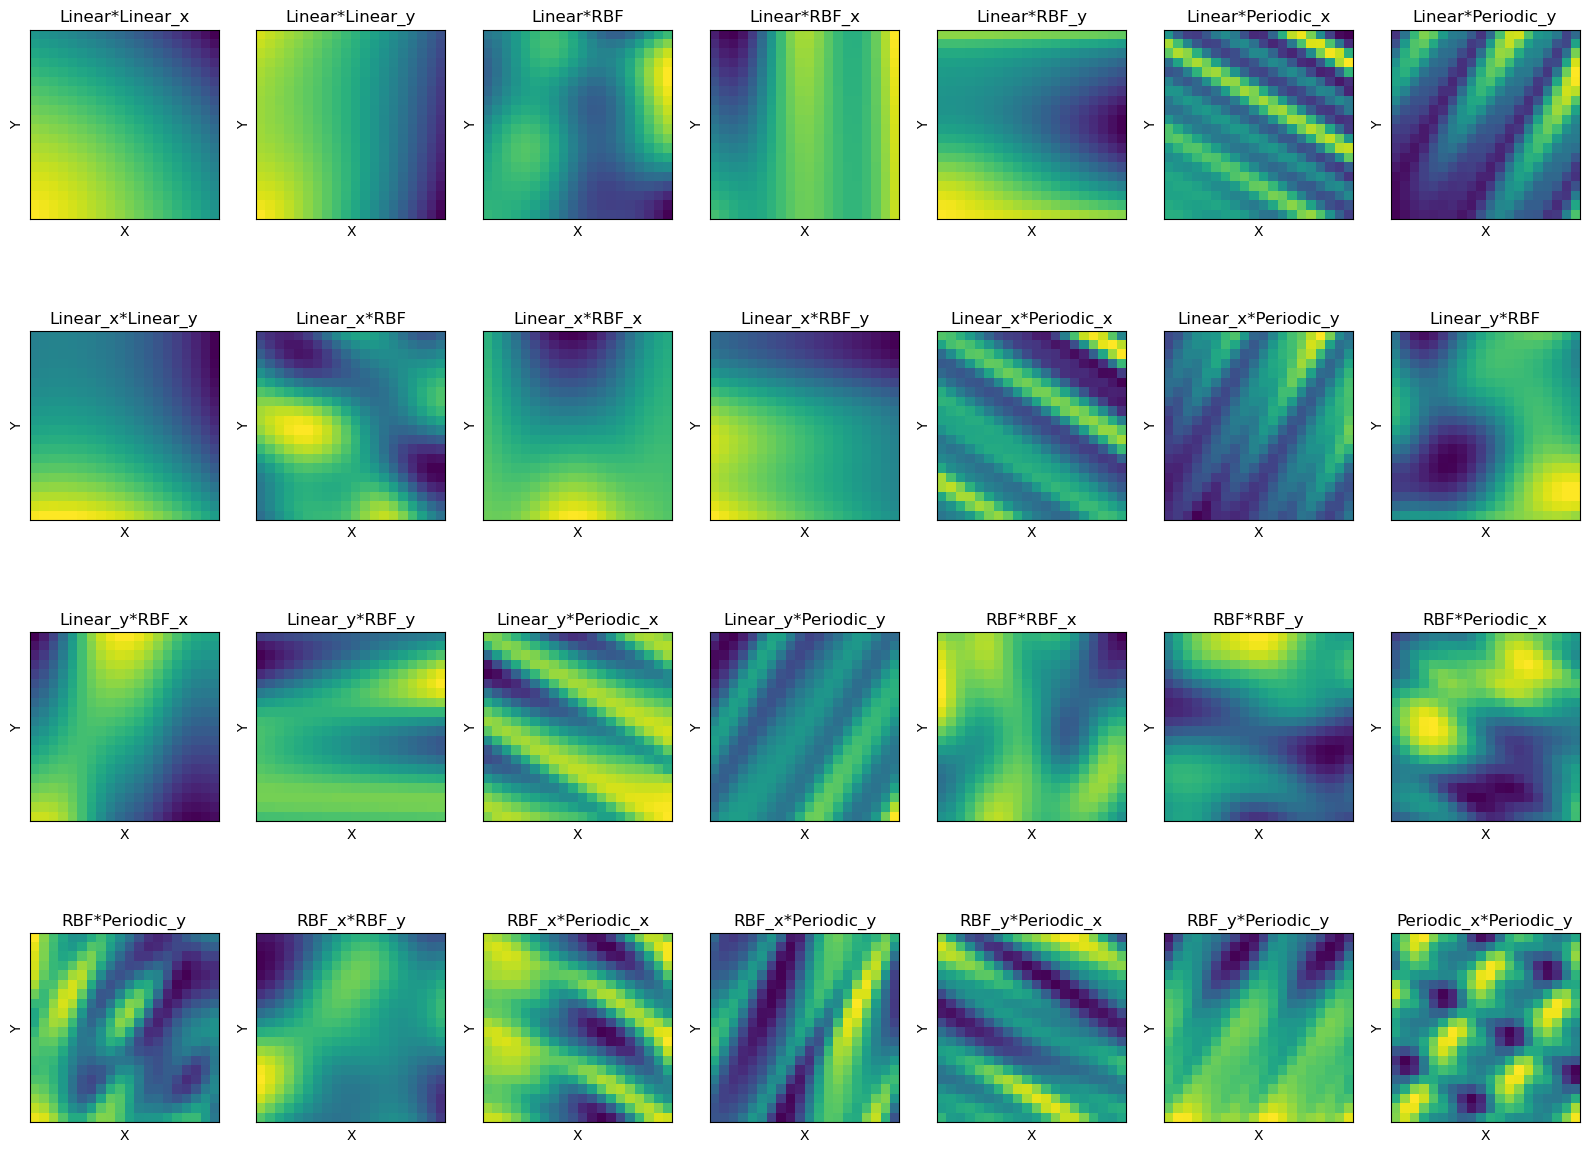

In [470]:
## get all possible products of kernels (i.e. K1*K2 from koi)
combo_koi = list(itertools.combinations(koi, 2))
combo_names = list(itertools.combinations(kernel_names,2))

## init subplot
plt.figure(figsize = (20,15))
for c in range(len(combo_koi)):
    combo_k = combo_koi[c][0]*combo_koi[c][1]
    ax = plt.subplot(4,7,c+1, )
    samples = GP.sample(combo_k)
    title = combo_names[c][0]+'*'+combo_names[c][1]
    GP.plot_r(samples, ax, title)

